In [1]:
!pip install wfdb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 4.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import json


# Define dataset path
data_path = "/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"

# Load SCP-ECG Statements (Error Handling Applied)
try:
    scp_df = pd.read_csv(data_path + "scp_statements.csv", encoding='utf-8')
except Exception as e:
    print("Error loading scp_statements.csv:", e)

# Load PTB-XL Metadata (Error Handling Applied)
try:
    df = pd.read_csv(data_path + "ptbxl_database.csv", encoding='utf-8')
except Exception as e:
    print("Error loading ptbxl_database.csv:", e)


# Drop rows where diagnostic_class is missing (important for classification)
scp_df_clean = scp_df.dropna(subset=["diagnostic_class"]).copy()  # Explicit Copy

# Fill missing values for subclass and category labels
scp_df_clean.loc[:, "diagnostic_subclass"] = scp_df_clean["diagnostic_subclass"].fillna("Unknown")

# Drop columns with >70% missing data
drop_cols = ["AHA code", "aECG REFID", "CDISC Code", "DICOM Code", "form", "rhythm"]
scp_df_clean = scp_df_clean.drop(columns=drop_cols)  # No `inplace=True`

# Display cleaned dataset info
print("Cleaned SCP-ECG Statements Data:\n", scp_df_clean.info())

# Fill missing numerical values with median
num_cols = ["age", "height", "weight"]
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values with "Unknown"
cat_cols = ["sex", "device", "validated_by", "site"]
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Convert recording_date to datetime
df["recording_date"] = pd.to_datetime(df["recording_date"], errors="coerce")

# Drop any remaining rows with critical missing data
df_clean = df.dropna()

# Display cleaned dataset info
print("Cleaned PTB-XL Database Data:\n", df_clean.info())

# Check for any remaining missing values
print("Remaining Missing Values in SCP:\n", scp_df_clean.isnull().sum())
print("\nRemaining Missing Values in PTB-XL:\n", df_clean.isnull().sum())

# Save cleaned data for faster processing later
scp_df_clean.to_csv("cleaned_scp_statements.csv", index=False)
df_clean.to_csv("cleaned_ptbxl_database.csv", index=False)

print("Cleaned datasets saved successfully!")

# Add full file paths for high-resolution (500 Hz) and low-resolution (100 Hz) ECG files
df["file_path_500"] = data_path + df["filename_hr"]  # 500Hz file paths
df["file_path_100"] = data_path + df["filename_lr"]  # 100Hz file paths

# Confirm that the columns are now present
print("Available Columns in DataFrame After Fix:\n", df.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 43
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     44 non-null     object 
 1   description                    44 non-null     object 
 2   diagnostic                     44 non-null     float64
 3   diagnostic_class               44 non-null     object 
 4   diagnostic_subclass            44 non-null     object 
 5   Statement Category             44 non-null     object 
 6   SCP-ECG Statement Description  44 non-null     object 
dtypes: float64(1), object(6)
memory usage: 2.8+ KB
Cleaned SCP-ECG Statements Data:
 None
<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ecg_id                        0 non-null      i

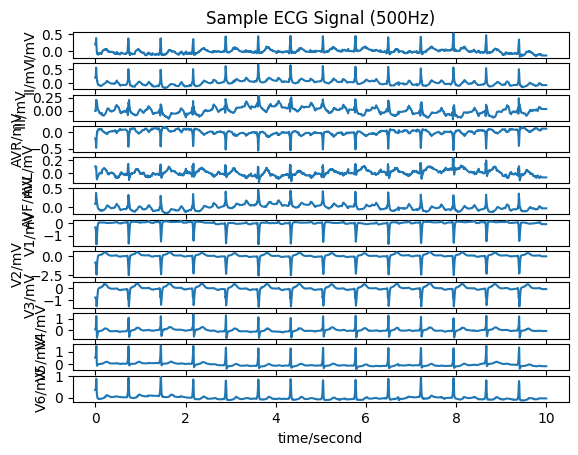

In [3]:
# Define file path for a sample record
record_path = data_path + "records500/21000/21428_hr"

# Load ECG data
record = wfdb.rdrecord(record_path)
# Plot and return the figure object
fig = wfdb.plot_wfdb(record=record, title="Sample ECG Signal (500Hz)", return_fig=True)

# Save the figure
fig.savefig("sample_ecg_500hz.png", dpi=300, bbox_inches='tight')

In [4]:
import wfdb
import matplotlib.pyplot as plt

# Load ECG record
record_path = data_path + "records500/21000/21428_hr"
record = wfdb.rdrecord(record_path)

# Plot and get the figure
fig = wfdb.plot_wfdb(record=record, return_fig=True)

# Resize to 224x224 pixels
fig.set_size_inches(2.24, 2.24)

# Remove axis labels and ticks for all subplots
for ax in fig.axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

# Save figure
fig.savefig("ecg_224x224_clean.png", dpi=100, bbox_inches='tight', pad_inches=0)
plt.close(fig)



✅ Final Binary Label Distribution:
diagnostic_class
NORM    9202
ABN     8295
Name: count, dtype: int64

✅ Sample Metadata with Labels:
                                  scp_codes diagnostic_class  label
0  {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}             NORM      0
1              {'NORM': 80.0, 'SBRAD': 0.0}             NORM      0
2                {'NORM': 100.0, 'SR': 0.0}             NORM      0
3                {'NORM': 100.0, 'SR': 0.0}             NORM      0
4                {'NORM': 100.0, 'SR': 0.0}             NORM      0

✅ Columns in df_metadata: Index(['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse',
       'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold'

100%|██████████| 17497/17497 [05:49<00:00, 50.01it/s]


✅ Loaded ECG Subset Shape (100Hz): (17497, 1000, 12)
✅ Label Distribution in Processed Data:
diagnostic_class
NORM    9202
ABN     8295
Name: count, dtype: int64
                                       file_path_100  \
0  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...   
1  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...   
2  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...   
3  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...   
4  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...   

                                       file_path_500 diagnostic_class  label  
0  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...              ABN      1  
1  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...             NORM      0  
2  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...             NORM      0  
3  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...              ABN      1  
4  /kaggle/input/ptb-xl-dataset/ptb-xl-a-large-pu...              ABN      1  


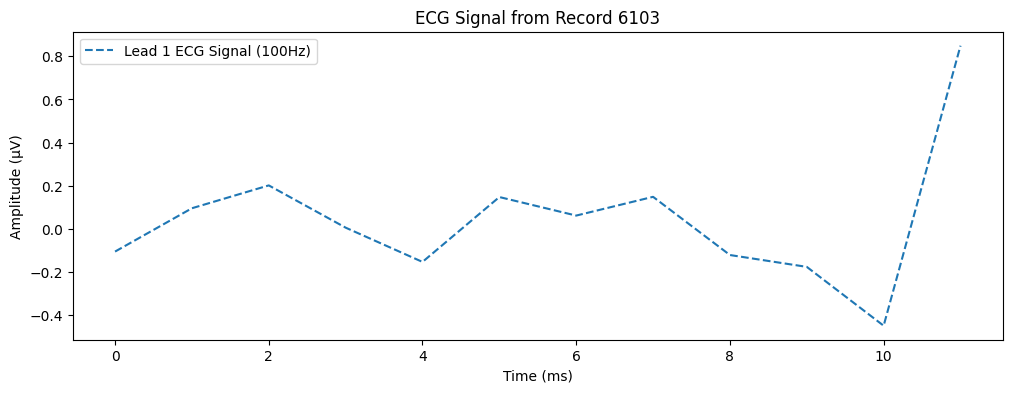

In [5]:
import pandas as pd
import numpy as np
import ast  # To parse scp_codes from string to dictionary
import wfdb
from tqdm import tqdm
import matplotlib.pyplot as plt

# ✅ Load cleaned metadata
df_metadata = pd.read_csv("/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/ptbxl_database.csv")

# ✅ Convert 'scp_codes' column from string to dictionary
df_metadata["scp_codes"] = df_metadata["scp_codes"].apply(ast.literal_eval)

# ✅ Define MI and STTC labels
mi_labels = ['INJAS', 'ILMI', 'INJIL', 'PMI', 'ISCAL', 'ISCLA', 'AMI', 'LMI', 'INJAL', 
             'ALMI', 'INJIN', 'IPMI', 'ISC_', 'IMI', 'ISCAS', 'ISCIN', 'INJLA', 'ISCIL', 
             'ISCAN', 'IPLMI', 'ASMI']
sttc_labels = ['NST_', 'STE_', 'STD_', 'STACH']

# ✅ Function to assign diagnostic class
def assign_diagnostic_class(scp_dict):
    scp_keys = list(scp_dict.keys())
    if any(label in scp_keys for label in mi_labels):
        return "MI"
    elif any(label in scp_keys for label in sttc_labels):
        return "STTC"
    elif "NORM" in scp_keys:
        return "NORM"
    return "OTHER"

# ✅ Apply function to dataset
df_metadata["diagnostic_class"] = df_metadata["scp_codes"].apply(assign_diagnostic_class)

# ✅ Filter out OTHER
df_metadata = df_metadata[df_metadata["diagnostic_class"] != "OTHER"]

# ✅ Reassign MI and STTC into ABNORM for binary classification
df_metadata["diagnostic_class"] = df_metadata["diagnostic_class"].apply(lambda x: "NORM" if x == "NORM" else "ABN")

# ✅ Encode binary labels: NORM = 0, ABNORM = 1
label_mapping = {"NORM": 0, "ABN": 1}
df_metadata["label"] = df_metadata["diagnostic_class"].map(label_mapping)

# ✅ Print updated label distribution
print("\n✅ Final Binary Label Distribution:")
print(df_metadata["diagnostic_class"].value_counts())

# ✅ Display sample metadata
print("\n✅ Sample Metadata with Labels:")
print(df_metadata[["scp_codes", "diagnostic_class", "label"]].head())

# ✅ Define file paths (ensure data_path is defined)
data_path = "/kaggle/input/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/"
df_metadata["file_path_100"] = data_path + df_metadata["filename_lr"]
df_metadata["file_path_500"] = data_path + df_metadata["filename_hr"]

# ✅ Debug: Check columns
print("\n✅ Columns in df_metadata:", df_metadata.columns)

# ✅ Sample data preview
print(df_metadata[["file_path_100", "file_path_500", "label"]].head())

# ✅ Function to load ECG signal
def load_ecg(record_path):
    record = wfdb.rdrecord(record_path)
    return np.array(record.p_signal)  # ECG signal as NumPy array

# ✅ Downsample Normal class (if needed) to balance dataset
norm_samples = df_metadata[df_metadata["diagnostic_class"] == "NORM"]
abnorm_samples = df_metadata[df_metadata["diagnostic_class"] == "ABN"]
df_balanced = pd.concat([norm_samples, abnorm_samples])

# ✅ Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# ✅ New label distribution
print("✅ New Dataset Size:")
print(df_balanced["diagnostic_class"].value_counts())

# ✅ Load ECG signals (100Hz only for memory efficiency)
subset_size = len(df_balanced)
ecg_100Hz = np.array([load_ecg(f) for f in tqdm(df_balanced["file_path_100"][:subset_size])])

# ✅ ECG data shape
print("✅ Loaded ECG Subset Shape (100Hz):", ecg_100Hz.shape)

# ✅ Final label distribution check
print("✅ Label Distribution in Processed Data:")
print(df_balanced["diagnostic_class"].value_counts())

# ✅ Debug: Preview of file paths and labels
print(df_balanced[["file_path_100", "file_path_500", "diagnostic_class", "label"]].head())

# ✅ Plot a random ECG signal (first lead)
sample_idx = np.random.randint(0, ecg_100Hz.shape[0])
plt.figure(figsize=(12, 4))
plt.plot(ecg_100Hz[sample_idx, 0, :], label="Lead 1 ECG Signal (100Hz)", linestyle="dashed")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude (µV)")
plt.title(f"ECG Signal from Record {sample_idx}")
plt.legend()
plt.show()


In [6]:
from sklearn.model_selection import train_test_split

# ✅ Prepare features (X) and labels (y)
X = ecg_100Hz  # Shape: (samples, leads, time)
y = df_balanced["label"].values  # 0 = NORM, 1 = ABNORM

# ✅ Identify normal (healthy) indices
healthy_indices = np.where(y == 0)[0]
abnorm_indices = np.where(y == 1)[0]

# ✅ Split healthy data for training the autoencoder
x_healthy = X[healthy_indices]
x_healthy_train, x_healthy_test = train_test_split(x_healthy, test_size=0.2, random_state=42)

# ✅ Split entire dataset for evaluation
x_all_train, x_all_test, y_all_train, y_all_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ✅ Final checks
print("\n✅ Autoencoder Training Data (Healthy Only):")
print("Train:", x_healthy_train.shape, " Test:", x_healthy_test.shape)

print("\n✅ Evaluation Dataset (All Data):")
print("Train:", x_all_train.shape, " Test:", x_all_test.shape)
print("Train labels:", np.bincount(y_all_train))
print("Test labels:", np.bincount(y_all_test))



✅ Autoencoder Training Data (Healthy Only):
Train: (7361, 1000, 12)  Test: (1841, 1000, 12)

✅ Evaluation Dataset (All Data):
Train: (13997, 1000, 12)  Test: (3500, 1000, 12)
Train labels: [7361 6636]
Test labels: [1841 1659]


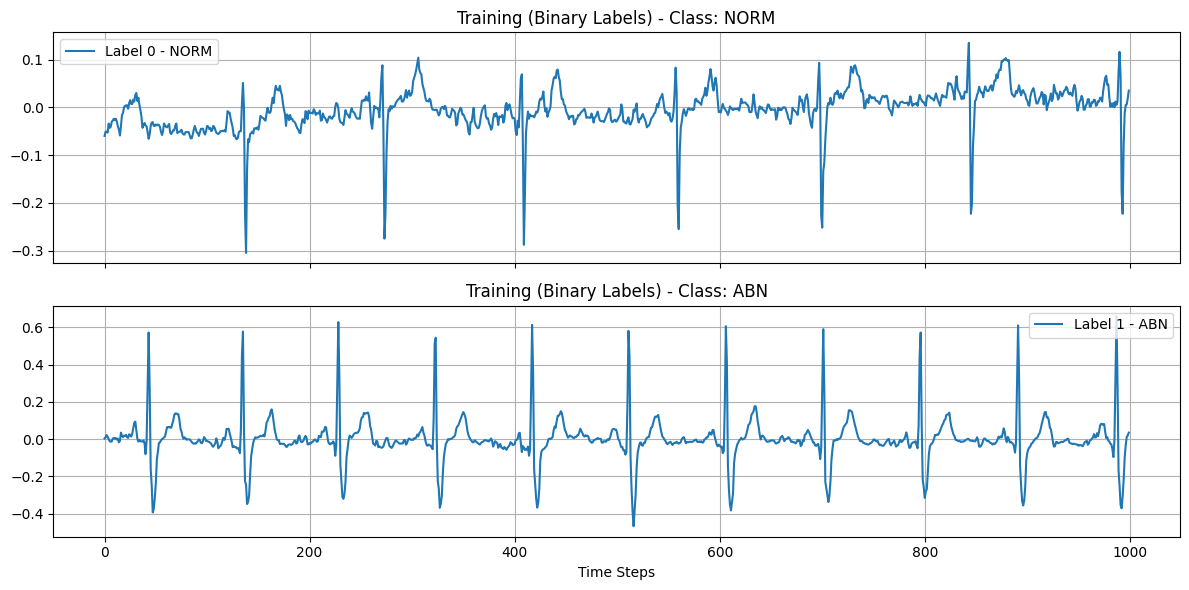

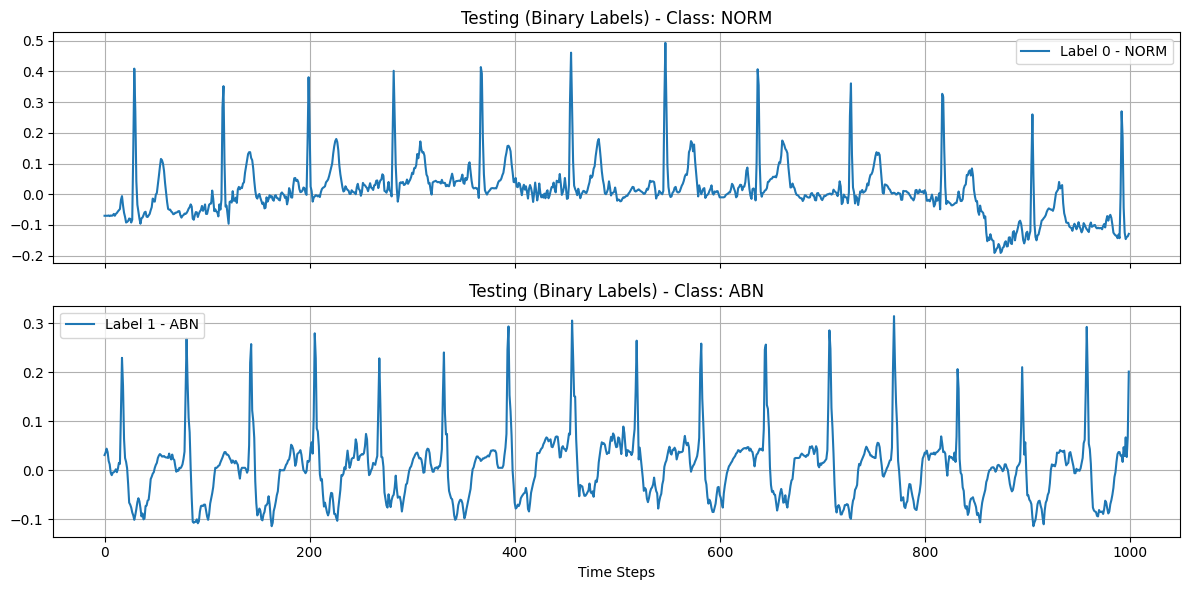

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ Update label titles for binary classification
label_title = ["NORM", "ABN"]

# ✅ Function to plot ECG samples
def plot_ecg_samples(X_data, y_data, dataset_name):
    unique_labels = np.unique(y_data)
    fig, axes = plt.subplots(len(unique_labels), 1, figsize=(12, 6), sharex=True)

    for i, label in enumerate(unique_labels):
        # Find the first sample for each class
        sample_idx = np.where(y_data == label)[0][0]
        
        # Plot only Lead I (first channel)
        axes[i].plot(X_data[sample_idx, :, 0], label=f"Label {label} - {label_title[label]}")
        axes[i].set_title(f"{dataset_name} - Class: {label_title[label]}")
        axes[i].legend()
        axes[i].grid(True)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

# ✅ Show samples from your full classification dataset
plot_ecg_samples(x_all_train, y_all_train, "Training (Binary Labels)")
plot_ecg_samples(x_all_test, y_all_test, "Testing (Binary Labels)")


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, LSTM, Dense
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2


def build_cnn_lstm_binary(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(32, 5, activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Conv1D(64, 5, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Conv1D(128, 5, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(128, return_sequences=True)(x)
    x = LSTM(64, return_sequences=False)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation="sigmoid")(x)  # Binary output
    return Model(inputs, outputs)

def build_cnn_gru_binary(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 5, activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Conv1D(128, 3, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = GRU(128, dropout=0.1)(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)

def build_cnn_bilstm_binary(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(32, 5, activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Conv1D(64, 5, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Conv1D(128, 5, activation="relu", padding="same")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Bidirectional(LSTM(64))(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation="sigmoid")(x)
    return Model(inputs, outputs)


2025-04-29 04:00:19.604059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745899219.785285      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745899219.838089      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [9]:
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

input_shape = (x_all_train.shape[1], x_all_train.shape[2])


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

# ✅ Class labels
class_names = ["NORM", "ABNORM"]

# ✅ Function to Plot Training History
def plot_training_history(history, title="Model Performance"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='red')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()



    plt.tight_layout()
    plt.savefig(f"his_{title}.png", dpi=300, bbox_inches="tight", format='png')
    plt.show()

# ✅ Function to Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, classes=class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"conf_{title}.png", dpi=300, bbox_inches="tight", format='png')
    plt.show()

# ✅ Function to Display Classification Report
def display_classification_report(y_true, y_pred, title="Classification Report"):
    print(f"\n🔹 {title}\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

# ✅ Function to Plot ROC Curve
def plot_roc_curve_binary(y_true, y_probs, title="ROC Curve - Binary"):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid()
    plt.tight_layout()
    plt.savefig(f"roc_{title}.png", dpi=300, bbox_inches="tight", format='png')
    plt.show()

# ✅ Function to Plot Precision-Recall Curve
def plot_precision_recall_curve_binary(y_true, y_probs, title="Precision-Recall Curve - Binary"):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label="Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"prec_{title}.png", dpi=300, bbox_inches="tight", format='png')
    plt.show()


In [11]:
initial_learning_rate = 0.001
lr_schedule = CosineDecay(initial_learning_rate, decay_steps=30, alpha=0.1)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)


In [12]:
model_binary = build_cnn_lstm_binary(input_shape)  # Output layer changed to 1 neuron with sigmoid
model_binary.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

history_binary = model_binary.fit(
    x_all_train, y_all_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)


I0000 00:00:1745899232.623112      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745899232.623821      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/50


I0000 00:00:1745899242.072450      70 cuda_dnn.cc:529] Loaded cuDNN version 90300


394/394 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.6514 - loss: 0.6294 - val_accuracy: 0.7243 - val_loss: 0.5810 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.6590 - loss: 0.6168 - val_accuracy: 0.8264 - val_loss: 0.4264 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.7835 - loss: 0.4852 - val_accuracy: 0.7950 - val_loss: 0.4584 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.7667 - loss: 0.4994 - val_accuracy: 0.8200 - val_loss: 0.4169 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8253 - loss: 0.4082 - val_accuracy: 0.7700 - val_loss: 0.4996 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8322 - loss: 0.4040 - val_accuracy: 0.8264 - val_loss: 0.3825 - learning_rate: 0.0010
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8534 - loss: 0.3514

110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step
✅ Test Accuracy: 90.34%


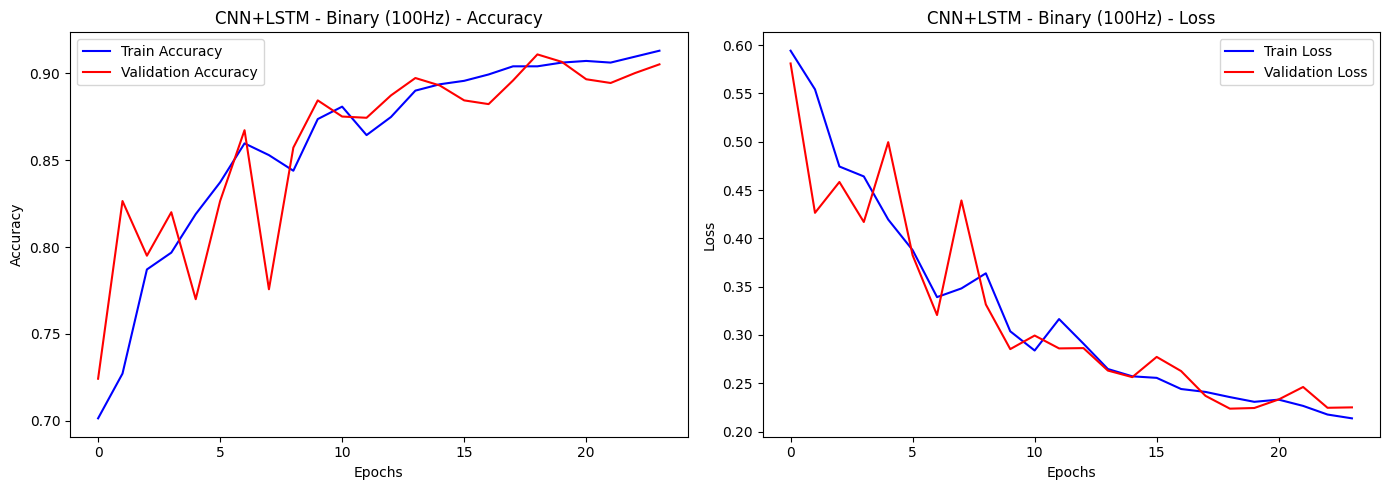

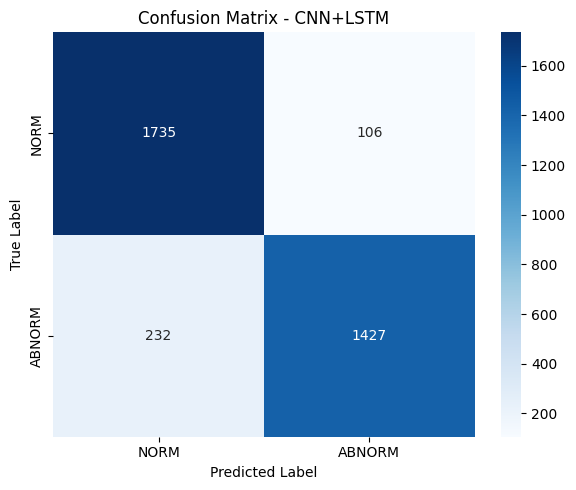


🔹 Classification Report - CNN+LSTM

              precision    recall  f1-score   support

        NORM       0.88      0.94      0.91      1841
      ABNORM       0.93      0.86      0.89      1659

    accuracy                           0.90      3500
   macro avg       0.91      0.90      0.90      3500
weighted avg       0.91      0.90      0.90      3500



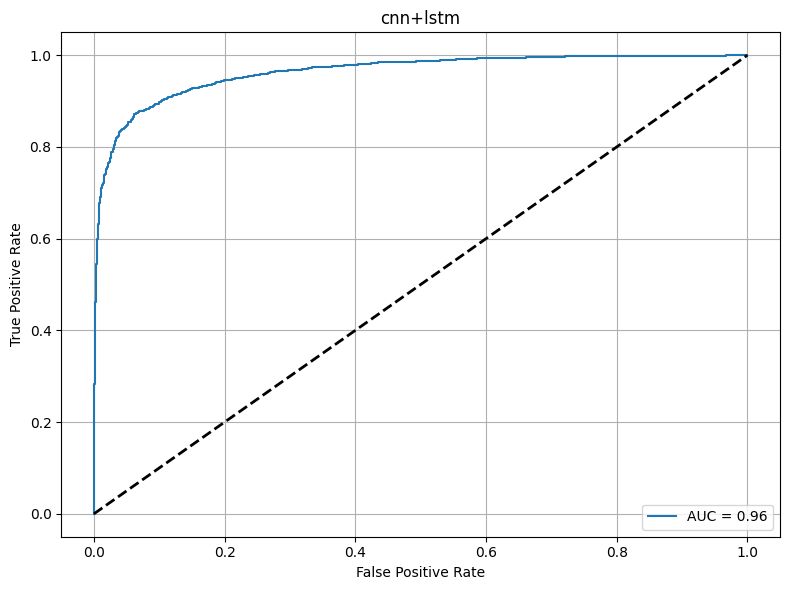

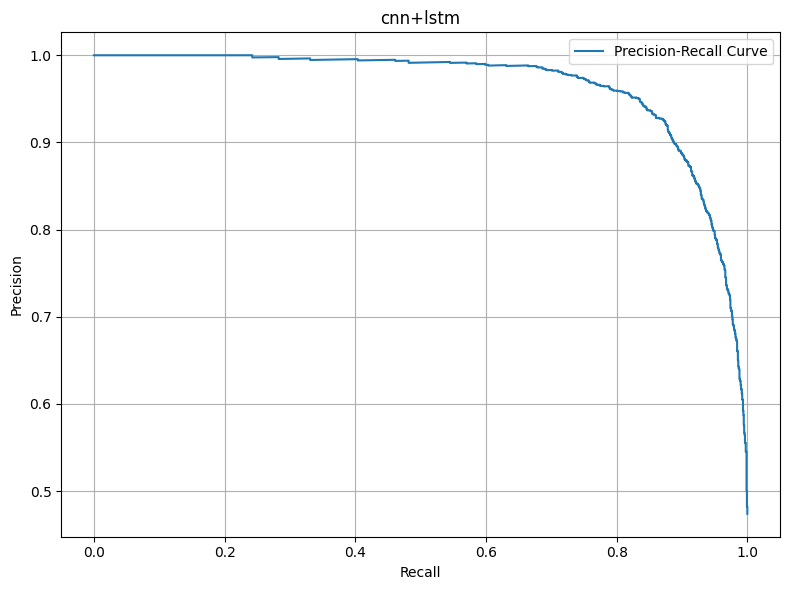

✅ Binary Classification Evaluation Complete!


In [13]:

# Save training history
with open("history_binary_lstm.json", "w") as f:
    json.dump(history_binary.history, f)
    
model_binary.save('model_100hz_lstm_binary.h5')

# ⚠️ After training your model:
# model_binary.fit(...) is done

# ➕ Evaluate on test set


# ✅ Predict probabilities and binary labels
y_pred_probs = model_binary.predict(x_all_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

# ✅ Calculate Accuracy
test_accuracy = accuracy_score(y_all_test, y_pred)
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")

# ➕ Plot & Print Results
plot_training_history(history_binary, title="CNN+LSTM - Binary (100Hz)")
plot_confusion_matrix(y_all_test, y_pred, title="Confusion Matrix - CNN+LSTM")
display_classification_report(y_all_test, y_pred, title="Classification Report - CNN+LSTM")
plot_roc_curve_binary(y_all_test, y_pred_probs, title="cnn+lstm")
plot_precision_recall_curve_binary(y_all_test, y_pred_probs, title="cnn+lstm")

print("✅ Binary Classification Evaluation Complete!")


# GRU

In [14]:
initial_learning_rate = 0.001
lr_schedule = CosineDecay(initial_learning_rate, decay_steps=30, alpha=0.1)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)


In [15]:
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Dropout, GRU, Dense, Bidirectional

gru_binary = build_cnn_gru_binary(input_shape)  # Output layer changed to 1 neuron with sigmoid
gru_binary.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

history_gru_binary = gru_binary.fit(
    x_all_train, y_all_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

# Save training history
with open("history_binary_gru.json", "w") as f:
    json.dump(history_gru_binary.history, f)
    
gru_binary.save('model_100hz_gru_binary.h5')



Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.5754 - loss: 0.7604 - val_accuracy: 0.6671 - val_loss: 0.6879 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - accuracy: 0.6922 - loss: 0.6427 - val_accuracy: 0.6907 - val_loss: 0.6041 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.7747 - loss: 0.5107 - val_accuracy: 0.8229 - val_loss: 0.4233 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8552 - loss: 0.3801 - val_accuracy: 0.8714 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8754 - loss: 0.3323 - val_accuracy: 0.8700 - val_loss: 0.3080 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8791 - loss: 0.3085 - val_accuracy: 0.8836 - val_loss: 0.2865 - learning_rate: 0.0010
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8832 - l

110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
✅ Test Accuracy: 89.89%


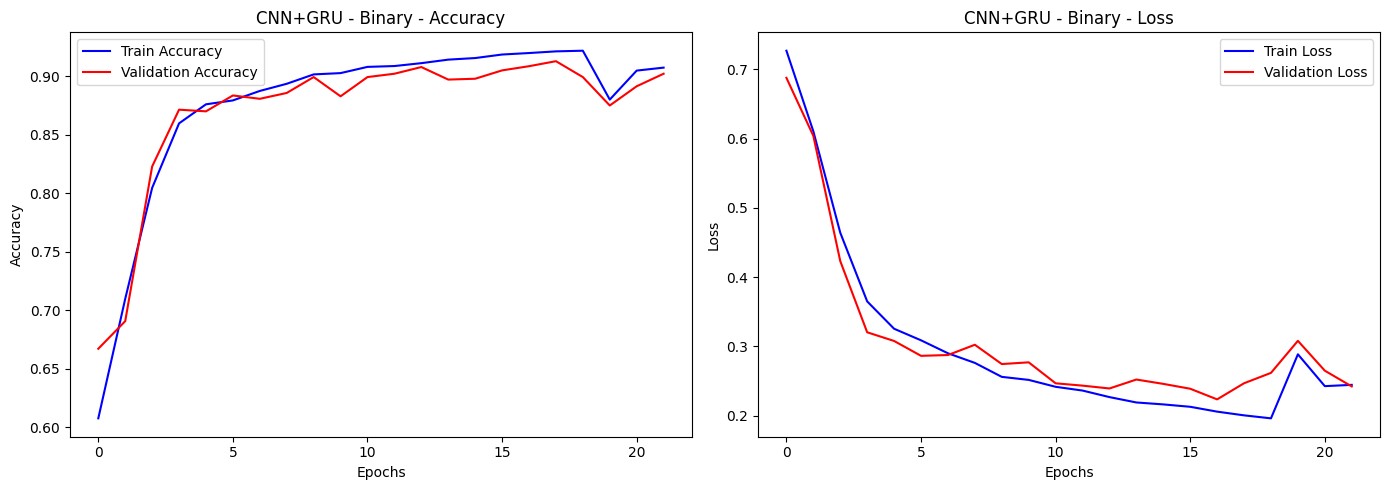

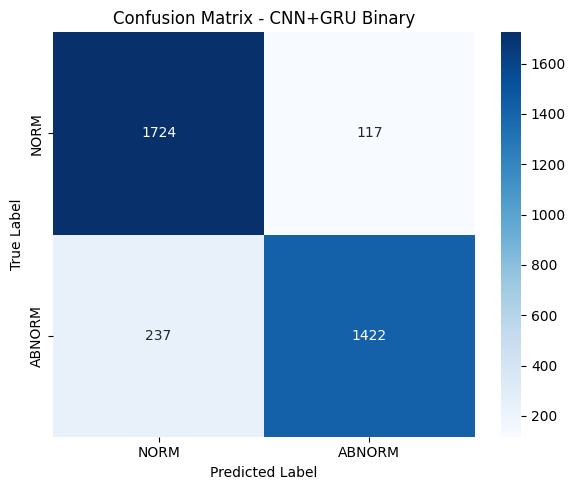


🔹 Classification Report - CNN+GRU Binary

              precision    recall  f1-score   support

        NORM       0.88      0.94      0.91      1841
      ABNORM       0.92      0.86      0.89      1659

    accuracy                           0.90      3500
   macro avg       0.90      0.90      0.90      3500
weighted avg       0.90      0.90      0.90      3500



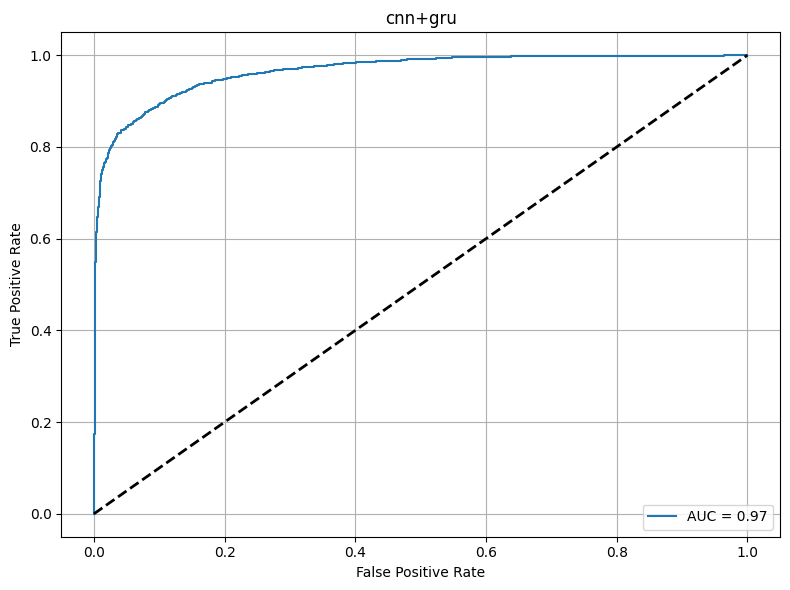

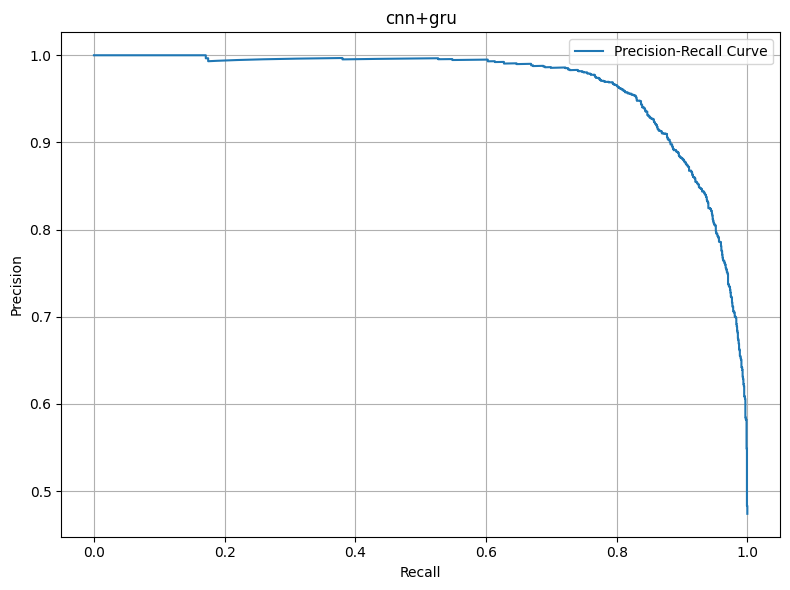

✅ Binary Classification Evaluation Complete!


In [16]:
# ⚠️ After training your model:
# model_binary.fit(...) is done

# ➕ Evaluate on test set
y_pred_probs = gru_binary.predict(x_all_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)  # Threshold for binary


# ✅ Calculate Accuracy
test_accuracy = accuracy_score(y_all_test, y_pred)
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")


# ➕ Plot & Print Results
plot_training_history(history_gru_binary, title="CNN+GRU - Binary")
plot_confusion_matrix(y_all_test, y_pred, title="Confusion Matrix - CNN+GRU Binary")
display_classification_report(y_all_test, y_pred, title="Classification Report - CNN+GRU Binary")
plot_roc_curve_binary(y_all_test, y_pred_probs, title="cnn+gru")
plot_precision_recall_curve_binary(y_all_test, y_pred_probs, title="cnn+gru")

print("✅ Binary Classification Evaluation Complete!")

# BiLSTM

In [17]:
initial_learning_rate = 0.001
lr_schedule = CosineDecay(initial_learning_rate, decay_steps=30, alpha=0.1)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)


Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 65s 144ms/step - accuracy: 0.6584 - loss: 0.6816 - val_accuracy: 0.7179 - val_loss: 0.6718 - learning_rate: 0.0010
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 140ms/step - accuracy: 0.7704 - loss: 0.5262 - val_accuracy: 0.8229 - val_loss: 0.4369 - learning_rate: 0.0010
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 56s 141ms/step - accuracy: 0.8136 - loss: 0.4563 - val_accuracy: 0.8136 - val_loss: 0.4284 - learning_rate: 0.0010
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 141ms/step - accuracy: 0.8323 - loss: 0.4212 - val_accuracy: 0.8421 - val_loss: 0.3796 - learning_rate: 0.0010
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 141ms/step - accuracy: 0.8149 - loss: 0.4317 - val_accuracy: 0.8357 - val_loss: 0.3791 - learning_rate: 0.0010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 141ms/step - accuracy: 0.8456 - loss: 0.3790 - val_accuracy: 0.8571 - val_loss: 0.3542 - learning_rate: 0.0010
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 55s 141ms/step - accuracy: 0.8

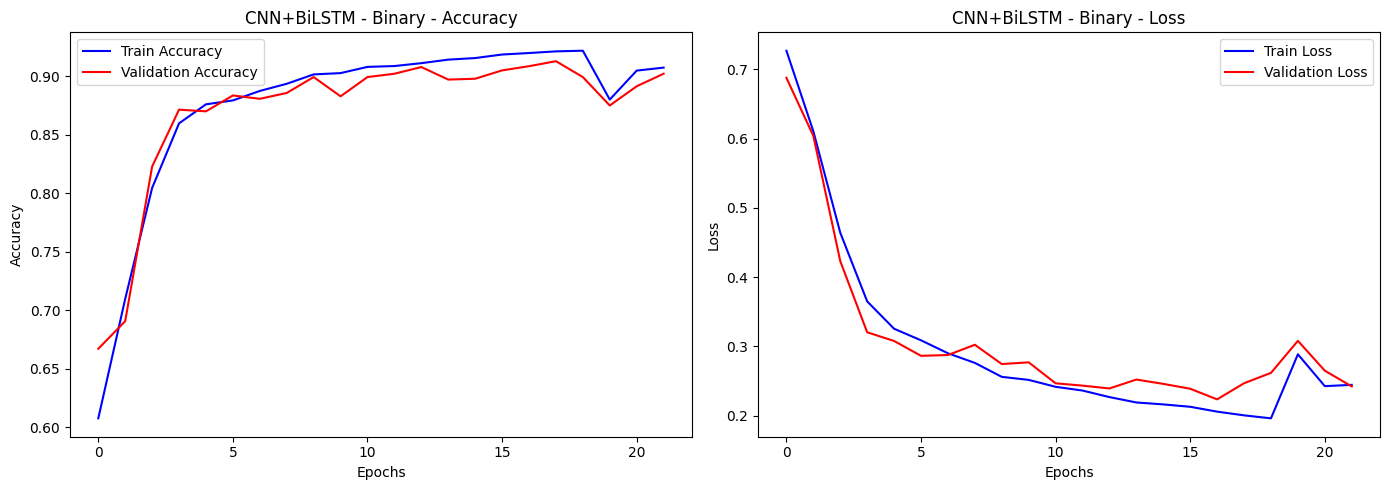

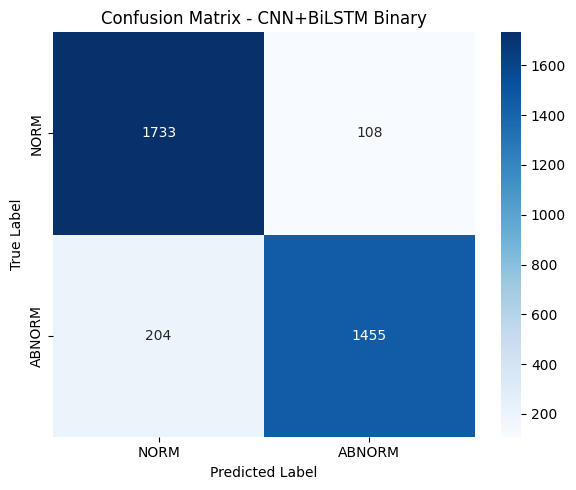


🔹 Classification Report - CNN+BiLSTM Binary

              precision    recall  f1-score   support

        NORM       0.89      0.94      0.92      1841
      ABNORM       0.93      0.88      0.90      1659

    accuracy                           0.91      3500
   macro avg       0.91      0.91      0.91      3500
weighted avg       0.91      0.91      0.91      3500



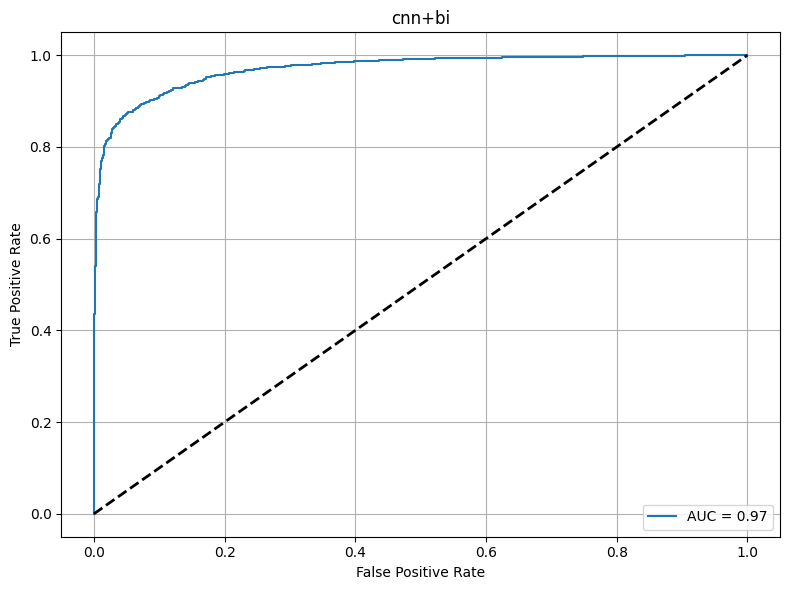

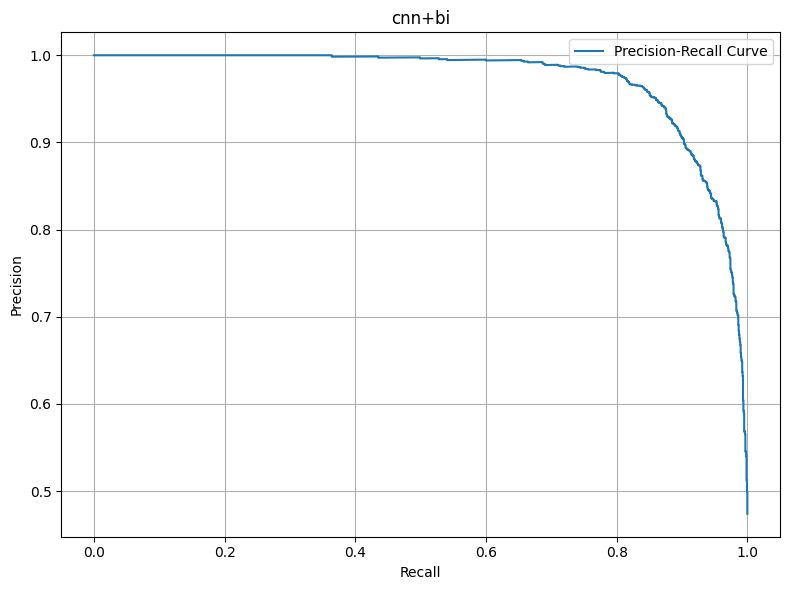

✅ Binary Classification Evaluation Complete!


In [18]:
bilstm_binary = build_cnn_bilstm_binary(input_shape)  # Output layer changed to 1 neuron with sigmoid
bilstm_binary.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

history_bilstm_binary = bilstm_binary.fit(
    x_all_train, y_all_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

# Save training history
with open("history_binary_bilstm.json", "w") as f:
    json.dump(history_bilstm_binary.history, f)
    
bilstm_binary.save('model_100hz_bilstm_binary.h5')

# ⚠️ After training your model:
# model_binary.fit(...) is done

# ➕ Evaluate on test set
y_pred_probs = bilstm_binary.predict(x_all_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)  # Threshold for binary

# ✅ Calculate Accuracy
test_accuracy = accuracy_score(y_all_test, y_pred)
print(f"✅ Test Accuracy: {test_accuracy * 100:.2f}%")

# ➕ Plot & Print Results
plot_training_history(history_gru_binary, title="CNN+BiLSTM - Binary")
plot_confusion_matrix(y_all_test, y_pred, title="Confusion Matrix - CNN+BiLSTM Binary")
display_classification_report(y_all_test, y_pred, title="Classification Report - CNN+BiLSTM Binary")
plot_roc_curve_binary(y_all_test, y_pred_probs, title="cnn+bi")
plot_precision_recall_curve_binary(y_all_test, y_pred_probs, title="cnn+bi")

print("✅ Binary Classification Evaluation Complete!")